# Confronto Classificatori — MaxViT-Tiny-512
## Real+Augmented vs Real+SyntheticPositive

Equivalente MaxViT-512 del confronto finale tra i classificatori addestrati con augmentation tradizionale e con campioni sintetici positivi.
Il notebook valuta le prestazioni sul test set reale mantenendo la stessa logica degli esperimenti precedenti:

| Configurazione | Dati di training | Notebook |
|---|---|---|
| **Real+Augmented** | Reali + augmentation tradizionale sui positivi | `18` |
| **Real+SyntheticPositive** | Reali + campioni positivi sintetici da diffusione fine-tuned | `19` |

L'obiettivo è confrontare i due classificatori MaxViT-512 tramite soglia di Youden calcolata sul validation set, metriche sul test set reale, ROC curve, confusion matrix e grafici riassuntivi.


In [9]:
# === Bootstrap unificato notebooks/ ===
# Funziona dalla root del progetto e da ogni sottocartella della struttura notebooks/.
import sys as _sys
from pathlib import Path as _Path


def _find_mammo_root():
    for _candidate in [_Path.cwd().resolve(), *_Path.cwd().resolve().parents]:
        if _candidate.name == "MammoDiffusion":
            return _candidate
        if (_candidate / "data").is_dir() and (_candidate / "notebooks").is_dir():
            return _candidate
    raise FileNotFoundError("Root MammoDiffusion non trovata da " + str(_Path.cwd()))


PROJECT_ROOT = _find_mammo_root()
NOTEBOOKS_DIR = PROJECT_ROOT / "notebooks"
UTILITY_DIR = NOTEBOOKS_DIR / "utility"
for _path in (str(UTILITY_DIR), str(NOTEBOOKS_DIR)):
    if _path not in _sys.path:
        _sys.path.insert(0, _path)

BASE = PROJECT_ROOT
BASE_DIR = PROJECT_ROOT
BASE_PATH = str(PROJECT_ROOT) + "/"
# === Fine bootstrap unificato ===

import os
import sys

# Controlla se il notebook sta girando su Google Colab
# [notebooks bootstrap] Il blocco Colab/local originale e' stato
# neutralizzato: BASE_PATH e BASE sono gia' definiti dal bootstrap
# unificato in cima al notebook.
print(f"Percorso base: ", BASE_PATH)

Ambiente locale rilevato.
Percorso base:  ../


#### Import librerie

In [10]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
from sklearn.metrics import (
    confusion_matrix, roc_curve, roc_auc_score,
    classification_report, precision_score, recall_score, f1_score,
)

sys.path.insert(0, os.getcwd())
from maxvit_utils import build_maxvit_model, resolve_normalization, make_dataloader, predict_probs, optimal_threshold_youden

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")

Device: cuda


#### Configurazione

In [11]:
TRAD_AUG_EXP_DIR  = os.path.join(BASE_PATH, 'experiments', 'classifiers/maxvit512/02e_real_augmented')
SYNTH_POS_EXP_DIR = os.path.join(BASE_PATH, 'experiments', 'classifiers/maxvit512/02f_real_synth_positive')

TEST_CSV_PATH = os.path.join(BASE_PATH, 'data', 'processed', 'metadata', 'test.csv')
VAL_CSV_PATH  = os.path.join(BASE_PATH, 'data', 'processed', 'metadata', 'val.csv')

IMG_SIZE = 512
BATCH_SIZE = 8
SEED = 42
IMAGENET_MEAN = (0.5, 0.5, 0.5)
IMAGENET_STD = (0.5, 0.5, 0.5)

OUTPUT_DIR      = os.path.join(BASE_PATH, 'results', 'classifiers/maxvit512/02y_compare_aug_vs_synth')
FIGURES_DIR     = os.path.join(OUTPUT_DIR, 'figures')
TABLES_DIR      = os.path.join(OUTPUT_DIR, 'tables')
PREDICTIONS_DIR = os.path.join(OUTPUT_DIR, 'predictions')
for d in (OUTPUT_DIR, FIGURES_DIR, TABLES_DIR, PREDICTIONS_DIR):
    os.makedirs(d, exist_ok=True)
print("output in:", OUTPUT_DIR)

output in: ../results/test_maxvit512_trad_aug_vs_synth_pos


#### Creazione Validation e Test dataset

In [12]:
df_val  = pd.read_csv(VAL_CSV_PATH).reset_index(drop=True)
df_test = pd.read_csv(TEST_CSV_PATH).reset_index(drop=True)
def fix_path(p):
    if os.path.isabs(p) or p.startswith('../') or p.startswith('./'):
        return p
    return os.path.join(BASE_PATH, p)

df_val['processed_path'] = df_val['processed_path'].apply(fix_path)
df_test['processed_path'] = df_test['processed_path'].apply(fix_path)

print("VAL :", len(df_val), " img  (malato=%d, sano=%d)" % ((df_val['cancer']==1).sum(), (df_val['cancer']==0).sum()))
print("TEST:", len(df_test), " img  (malato=%d, sano=%d)" % ((df_test['cancer']==1).sum(), (df_test['cancer']==0).sum()))

val_loader  = make_dataloader(df_val,  'processed_path', 'cancer', IMAGENET_MEAN, IMAGENET_STD, IMG_SIZE, batch_size=BATCH_SIZE, shuffle=False)
test_loader = make_dataloader(df_test, 'processed_path', 'cancer', IMAGENET_MEAN, IMAGENET_STD, IMG_SIZE, batch_size=BATCH_SIZE, shuffle=False)

VAL : 437  img  (malato=73, sano=364)
TEST: 438  img  (malato=73, sano=365)


#### Caricamento Modelli

In [13]:
model_trad_aug = build_maxvit_model(num_classes=1, pretrained=False)
_ckpt_path = os.path.join(TRAD_AUG_EXP_DIR, 'real_augmented_maxvit512_final_best.pt')
assert os.path.isfile(_ckpt_path), (
    f"Modello 'Real+Augmented' non trovato in {_ckpt_path}. "
    f"Esegui prima il notebook di training corrispondente."
)
model_trad_aug.load_state_dict(torch.load(_ckpt_path, map_location=DEVICE))
model_trad_aug.to(DEVICE)
print(f"[Real+Augmented] Modello caricato da: {_ckpt_path}")

[Real+Augmented] Modello caricato da: ../experiments/exp_maxvit512_real_augmented/real_augmented_maxvit512_final_best.pt


In [14]:
model_synth_pos = build_maxvit_model(num_classes=1, pretrained=False)
_ckpt_path = os.path.join(SYNTH_POS_EXP_DIR, 'synth_pos_maxvit512_final_best.pt')
assert os.path.isfile(_ckpt_path), (
    f"Modello 'Real+SyntheticPositive' non trovato in {_ckpt_path}. "
    f"Esegui prima il notebook di training corrispondente."
)
model_synth_pos.load_state_dict(torch.load(_ckpt_path, map_location=DEVICE))
model_synth_pos.to(DEVICE)
print(f"[Real+SyntheticPositive] Modello caricato da: {_ckpt_path}")

[Real+SyntheticPositive] Modello caricato da: ../experiments/exp_maxvit512_synth_pos/synth_pos_maxvit512_final_best.pt


In [15]:
modelli = {'Real+Augmented': model_trad_aug, 'Real+SyntheticPositive': model_synth_pos}
MODELLI_ATTIVI = list(modelli.keys())

#### Soglia di Youden (calcolata sul Validation Set)

In [16]:
from maxvit_utils import optimal_threshold_youden

soglie = {}
val_true = None
for nome, modello in modelli.items():
    yt, yp = predict_probs(modello, val_loader, DEVICE)
    val_true = yt
    soglie[nome] = optimal_threshold_youden(yt, yp)

print("soglie di Youden (VAL):")
for nome in MODELLI_ATTIVI:
    print("  %-22s %.4f" % (nome, soglie[nome]))

soglie di Youden (VAL):
  Real+Augmented         0.2663
  Real+SyntheticPositive 0.3416


#### Predizioni sul Test Set

In [17]:
test_probs = {}
test_true = None
for nome, modello in modelli.items():
    yt, yp = predict_probs(modello, test_loader, DEVICE)
    test_true = yt
    test_probs[nome] = yp

def _key(nome):
    return nome.lower().replace('+', '_')

df_pred = df_test[['processed_path', 'cancer']].copy().rename(columns={'cancer': 'label_true'})
for nome in MODELLI_ATTIVI:
    k = _key(nome)
    df_pred['prob_' + k] = test_probs[nome]
    df_pred['pred_' + k] = (test_probs[nome] >= soglie[nome]).astype(int)

preds_path = os.path.join(PREDICTIONS_DIR, 'test_predictions.csv')
df_pred.to_csv(preds_path, index=False)
print("predizioni salvate in:", preds_path)

predizioni salvate in: ../results/test_maxvit512_trad_aug_vs_synth_pos/predictions/test_predictions.csv


#### Valutazione — Metriche per Configurazione

In [18]:
from sklearn.metrics import accuracy_score

COLORS = {'Real+Augmented': 'tab:orange', 'Real+SyntheticPositive': 'tab:green'}
CLASSIFICATORI = {nome: (test_probs[nome], soglie[nome]) for nome in MODELLI_ATTIVI}

all_metrics = {}
for nome, (probs, thr) in CLASSIFICATORI.items():
    fpr, tpr, _ = roc_curve(test_true, probs)
    y_pred = (probs >= thr).astype(int)
    all_metrics[nome] = {
        'auc': round(float(roc_auc_score(test_true, probs)), 4),
        'threshold': round(float(thr), 4),
        'accuracy': round(float(accuracy_score(test_true, y_pred)), 4),
        'precision': round(float(precision_score(test_true, y_pred, pos_label=1, zero_division=0)), 4),
        'recall': round(float(recall_score(test_true, y_pred, pos_label=1, zero_division=0)), 4),
        'f1': round(float(f1_score(test_true, y_pred, pos_label=1, zero_division=0)), 4),
        'fpr': fpr, 'tpr': tpr, 'y_pred': y_pred,
    }
    print("\n[%s] AUC=%.4f F1=%.4f recall=%.4f acc=%.4f" % (
        nome, all_metrics[nome]['auc'], all_metrics[nome]['f1'],
        all_metrics[nome]['recall'], all_metrics[nome]['accuracy']))
    print(classification_report(test_true, y_pred, target_names=['Sano', 'Malato']))

delta = {}
if 'Real+Augmented' in all_metrics and 'Real+SyntheticPositive' in all_metrics:
    delta = {k: round(all_metrics['Real+SyntheticPositive'][k] - all_metrics['Real+Augmented'][k], 4)
             for k in ('auc', 'f1', 'recall', 'accuracy')}
    print("\ndelta (Real+SyntheticPositive - Real+Augmented):", delta)

metrics_to_save = {
    'modelli_attivi': MODELLI_ATTIVI,
    'configs': {k: {m: v for m, v in vals.items() if m not in ('fpr', 'tpr', 'y_pred')}
                for k, vals in all_metrics.items()},
    'delta_synth_pos_minus_real_augmented': delta,
}
out_json = os.path.join(TABLES_DIR, 'test_metrics_trad_aug_vs_synth_pos_maxvit512.json')
with open(out_json, 'w') as f:
    json.dump(metrics_to_save, f, indent=2, ensure_ascii=False)
print("\nmetriche salvate in:", out_json)


[Real+Augmented] AUC=0.6103 F1=0.3059 recall=0.7397 acc=0.4406
              precision    recall  f1-score   support

        Sano       0.88      0.38      0.53       365
      Malato       0.19      0.74      0.31        73

    accuracy                           0.44       438
   macro avg       0.54      0.56      0.42       438
weighted avg       0.77      0.44      0.49       438


[Real+SyntheticPositive] AUC=0.6199 F1=0.2843 recall=0.3973 acc=0.6667
              precision    recall  f1-score   support

        Sano       0.86      0.72      0.78       365
      Malato       0.22      0.40      0.28        73

    accuracy                           0.67       438
   macro avg       0.54      0.56      0.53       438
weighted avg       0.75      0.67      0.70       438


delta (Real+SyntheticPositive - Real+Augmented): {'auc': 0.0096, 'f1': -0.0216, 'recall': -0.3424, 'accuracy': 0.2261}

metriche salvate in: ../results/test_maxvit512_trad_aug_vs_synth_pos/tables/test_metrics_

#### ROC e Confusion Matrix

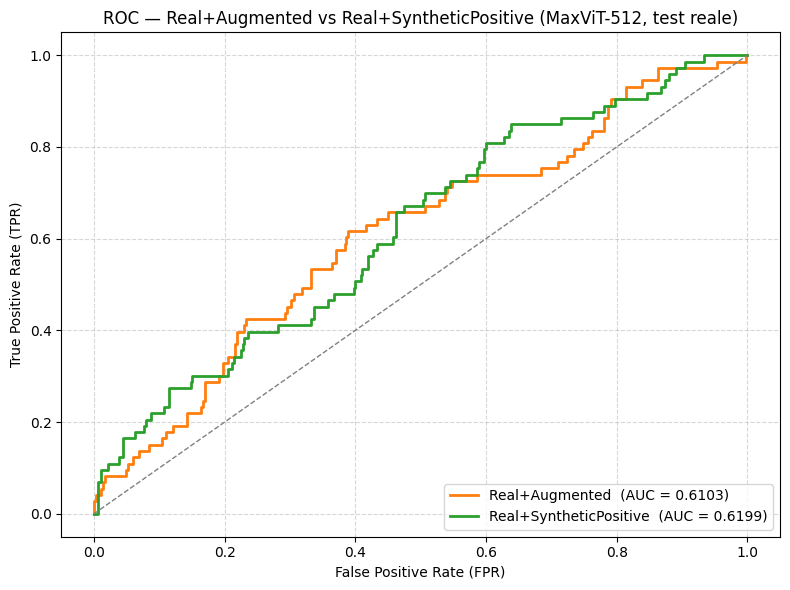

Salvato in: ../results/test_maxvit512_trad_aug_vs_synth_pos/figures/roc_trad_aug_vs_synth_pos_maxvit512.png


In [19]:
fig, ax = plt.subplots(figsize=(8, 6))
for nome_conf, m in all_metrics.items():
    ax.plot(m['fpr'], m['tpr'], color=COLORS[nome_conf], lw=2,
            label=f"{nome_conf}  (AUC = {m['auc']:.4f})")

ax.plot([0, 1], [0, 1], '--', color='gray', linewidth=1)
ax.set_xlabel('False Positive Rate (FPR)')
ax.set_ylabel('True Positive Rate (TPR)')
ax.set_title('ROC — Real+Augmented vs Real+SyntheticPositive (MaxViT-512, test reale)')
ax.legend(loc='lower right')
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
roc_path = os.path.join(FIGURES_DIR, 'roc_trad_aug_vs_synth_pos_maxvit512.png')
fig.savefig(roc_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Salvato in: {roc_path}")

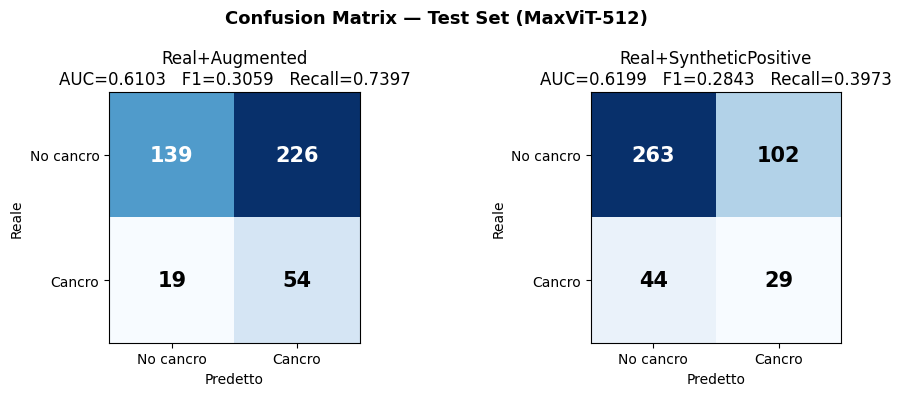

Salvato in: ../results/test_maxvit512_trad_aug_vs_synth_pos/figures/cm_trad_aug_vs_synth_pos_maxvit512.png


In [20]:
fig, axes = plt.subplots(1, len(all_metrics), figsize=(5 * len(all_metrics), 4), squeeze=False)
axes = axes[0]
for ax, (nome_conf, m) in zip(axes, all_metrics.items()):
    cm = confusion_matrix(test_true, m['y_pred'])
    ax.imshow(cm, cmap='Blues')
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(['No cancro', 'Cancro'])
    ax.set_yticklabels(['No cancro', 'Cancro'])
    ax.set_xlabel('Predetto'); ax.set_ylabel('Reale')
    ax.set_title(f'{nome_conf}\nAUC={m["auc"]:.4f}   F1={m["f1"]:.4f}   Recall={m["recall"]:.4f}')
    for i in range(2):
        for j in range(2):
            color = 'white' if cm[i, j] > cm.max() / 2 else 'black'
            ax.text(j, i, cm[i, j], ha='center', va='center', fontsize=15, fontweight='bold', color=color)

plt.suptitle('Confusion Matrix — Test Set (MaxViT-512)', fontsize=13, fontweight='bold')
plt.tight_layout()
cm_path = os.path.join(FIGURES_DIR, 'cm_trad_aug_vs_synth_pos_maxvit512.png')
fig.savefig(cm_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Salvato in: {cm_path}")

#### Confronto Metriche

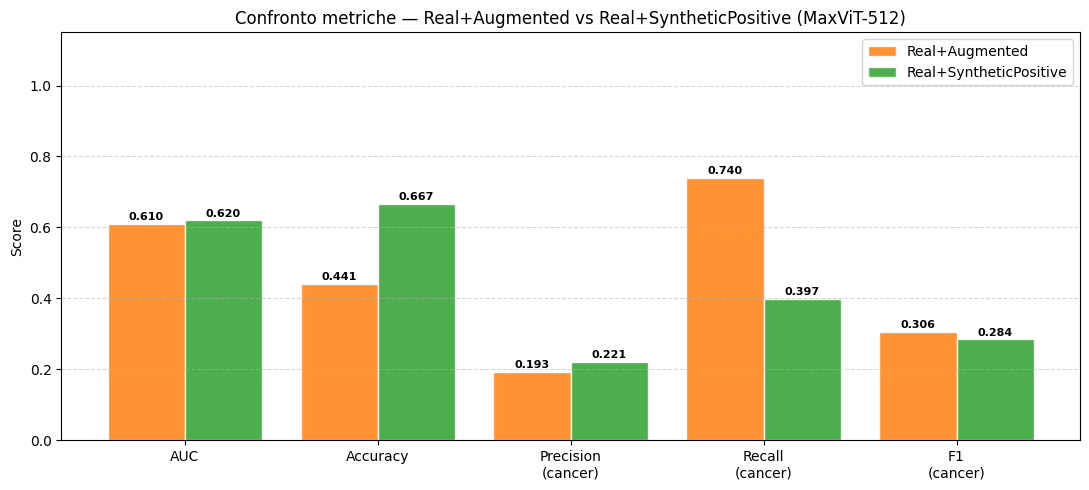

Salvato in: ../results/test_maxvit512_trad_aug_vs_synth_pos/figures/metrics_comparison_maxvit512.png


In [21]:
metric_keys   = ['auc', 'accuracy', 'precision', 'recall', 'f1']
metric_labels = ['AUC', 'Accuracy', 'Precision\n(cancer)', 'Recall\n(cancer)', 'F1\n(cancer)']

nomi = list(all_metrics.keys())
x = np.arange(len(metric_keys))
width = 0.8 / max(len(nomi), 1)

fig, ax = plt.subplots(figsize=(11, 5))
for i, nome_conf in enumerate(nomi):
    vals = [all_metrics[nome_conf][k] for k in metric_keys]
    bars = ax.bar(x + i * width, vals, width, label=nome_conf,
                  color=COLORS.get(nome_conf, 'tab:blue'), alpha=0.85, edgecolor='white')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.005,
                f'{v:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xticks(x + width * (len(nomi) - 1) / 2)
ax.set_xticklabels(metric_labels)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score')
ax.set_title('Confronto metriche — Real+Augmented vs Real+SyntheticPositive (MaxViT-512)')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
bar_path = os.path.join(FIGURES_DIR, 'metrics_comparison_maxvit512.png')
fig.savefig(bar_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Salvato in: {bar_path}")